# Tarea: Series de Tiempo

## Parte 1: Extracción de la data y entrenamiento del modelo

El conjunto de datos está totalmente dedicado a los desarrolladores que desean entrenar el modelo en Pronóstico del tiempo para el clima indio. Este conjunto de datos proporciona datos desde el 1 de enero de 2013 hasta el 24 de abril de 2017 en la ciudad de Delhi, India. Los 4 parámetros aquí son
temperatura media, humedad, wind_speed, presión media.

In [13]:
import pandas as pd

# Cargar datasets
train_path = "DailyDelhiClimateTrain.csv"
test_path  = "DailyDelhiClimate.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

def preparar_df(df):
    # 1) Limpiar nombres de columnas
    df.columns = df.columns.str.strip()
    
    # 2) Quitar columnas que no usaremos
    df = df.drop(columns=["Apertura", "Máximo", "Mínimo", "Vol.", "% var."], errors="ignore")
    
    # 3) Renombrar correctamente
    df = df.rename(columns={"date": "ds", "meantemp": "y"})
    
    # 4) Convertir 'y' a numérico si es necesario
    if df["y"].dtype == object:
        df["y"] = (
            df["y"].astype(str)
                   .str.replace(".", "", regex=False)
                   .str.replace(",", ".", regex=False)
        )
        df["y"] = pd.to_numeric(df["y"], errors="coerce")
    
    # 5) Ordenar por fecha y resetear índice
    df = df.sort_values("ds").reset_index(drop=True)
    return df

# Procesar ambos
df_train = preparar_df(df_train)
df_test  = preparar_df(df_test)

print("Train:")
print(df_train.head())
print("\nTest:")
print(df_test.head())

Train:
           ds          y   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000

Test:
           ds          y   humidity  wind_speed  meanpressure
0  2017-01-01  15.913043  85.869565    2.743478     59.000000
1  2017-01-02  18.500000  77.222222    2.894444   1018.277778
2  2017-01-03  17.111111  81.888889    4.016667   1018.333333
3  2017-01-04  18.700000  70.050000    4.545000   1015.700000
4  2017-01-05  18.388889  74.944444    3.300000   1014.333333


In [15]:
!pip install prophet

In [18]:
# =========================================
# 3) Prophet (solo TRAIN para evaluar en TEST)
# =========================================
from prophet import Prophet

# Asegurar que las fechas son datetime
df_train["ds"] = pd.to_datetime(df_train["ds"])
df_test["ds"]  = pd.to_datetime(df_test["ds"])

# 1) Entrenar modelo SOLO con TRAIN
m = Prophet()
m.fit(df_train[["ds", "y"]])

# 2) Construir futuro exactamente con las fechas de TEST
future_test = pd.DataFrame({"ds": df_test["ds"]})

# 3) Generar predicción SOLO en esas fechas
forecast_test = m.predict(future_test)

# 4) Vector de predicciones alineado a TEST
y_pred = forecast_test["yhat"].reset_index(drop=True)
y_true = df_test["y"].reset_index(drop=True)  # para comparar

y_pred

18:49:38 - cmdstanpy - INFO - Chain [1] start processing
18:49:38 - cmdstanpy - INFO - Chain [1] done processing


0      14.350417
1      14.560721
2      14.646778
3      14.813565
4      14.800330
         ...    
109    32.872454
110    33.016232
111    33.097831
112    33.144384
113    33.494851
Name: yhat, Length: 114, dtype: float64

In [19]:
forecast_test

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-01-01,27.518657,11.707502,16.992284,27.518657,27.518657,-13.168240,-13.168240,-13.168240,-0.195063,-0.195063,-0.195063,-12.973177,-12.973177,-12.973177,0.0,0.0,0.0,14.350417
1,2017-01-02,27.521538,12.042811,17.241373,27.521538,27.521538,-12.960817,-12.960817,-12.960817,-0.010773,-0.010773,-0.010773,-12.950044,-12.950044,-12.950044,0.0,0.0,0.0,14.560721
2,2017-01-03,27.524418,12.015994,17.304137,27.524418,27.524418,-12.877640,-12.877640,-12.877640,0.034028,0.034028,0.034028,-12.911668,-12.911668,-12.911668,0.0,0.0,0.0,14.646778
3,2017-01-04,27.527298,11.879613,17.437820,27.527298,27.527298,-12.713733,-12.713733,-12.713733,0.146257,0.146257,0.146257,-12.859990,-12.859990,-12.859990,0.0,0.0,0.0,14.813565
4,2017-01-05,27.530179,12.080585,17.506154,27.530179,27.530179,-12.729848,-12.729848,-12.729848,0.067150,0.067150,0.067150,-12.796998,-12.796998,-12.796998,0.0,0.0,0.0,14.800330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,2017-04-20,27.832614,30.260417,35.461285,27.750497,27.915177,5.039840,5.039840,5.039840,0.067150,0.067150,0.067150,4.972690,4.972690,4.972690,0.0,0.0,0.0,32.872454
110,2017-04-21,27.835494,30.343477,35.636015,27.752389,27.919036,5.180738,5.180738,5.180738,0.027528,0.027528,0.027528,5.153210,5.153210,5.153210,0.0,0.0,0.0,33.016232
111,2017-04-22,27.838375,30.564500,35.640557,27.753830,27.923461,5.259457,5.259457,5.259457,-0.069127,-0.069127,-0.069127,5.328583,5.328583,5.328583,0.0,0.0,0.0,33.097831
112,2017-04-23,27.841255,30.690722,35.768394,27.755650,27.927420,5.303129,5.303129,5.303129,-0.195063,-0.195063,-0.195063,5.498192,5.498192,5.498192,0.0,0.0,0.0,33.144384


In [20]:
# Métricas en TEST
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Valores reales de TEST
y_true = df_test["y"].values

# Calcular métricas
mae  = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)  # raíz del MSE

print(f"Prophet | MAE={mae:.4f} | RMSE={rmse:.4f}")

Prophet | MAE=2.1878 | RMSE=2.6636


/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


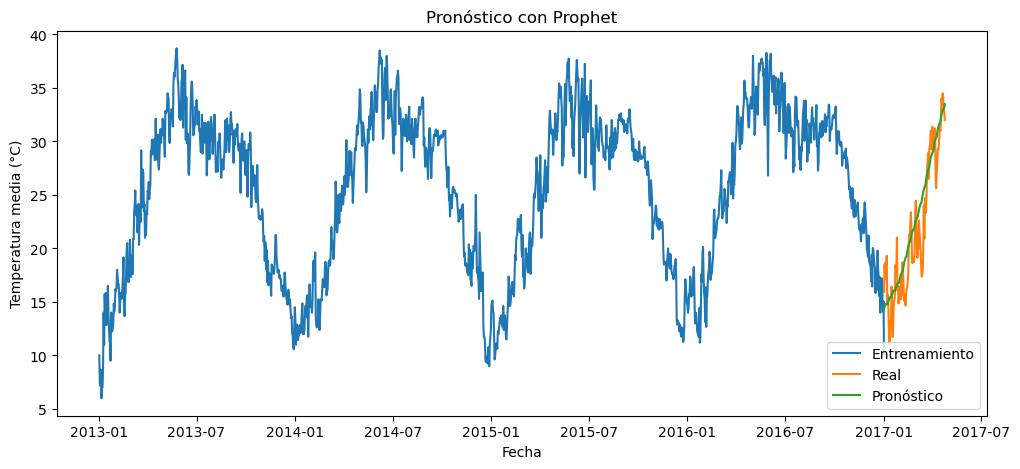

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Serie de entrenamiento
plt.plot(df_train["ds"], df_train["y"], label="Entrenamiento")

# Serie real en TEST
plt.plot(df_test["ds"], df_test["y"], label="Real")

# Pronóstico en TEST
plt.plot(df_test["ds"], y_pred, label="Pronóstico")

plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Temperatura media (°C)")
plt.title("Pronóstico con Prophet")
plt.show()

📊 **Explicación del gráfico de Pronóstico con Prophet**

En el gráfico aparecen tres líneas:

- **Azul (Entrenamiento):** son los datos históricos usados para entrenar el modelo.  
- **Naranja (Real):** son los valores verdaderos en el conjunto de prueba.  
- **Verde (Pronóstico):** son las predicciones del modelo para las mismas fechas del conjunto de prueba.

🔎 **¿Qué significa?**
- La línea azul muestra cómo se comportó la temperatura en el pasado (2013–2016).  
- La línea naranja muestra los valores reales del 2017 (datos de prueba).  
- La línea verde es lo que el modelo predijo para esas fechas.  

Si la línea verde (pronóstico) sigue de cerca a la naranja (real), quiere decir que el modelo **acertó bien** en sus predicciones.  
Las diferencias entre ambas líneas representan el **error de predicción**, que se mide con métricas como MAE o RMSE.  

✅ **Conclusión**
El modelo Prophet logró capturar los **patrones estacionales** de la temperatura (subidas y bajadas cada año) y pudo pronosticar de forma razonable los valores en el conjunto de prueba.


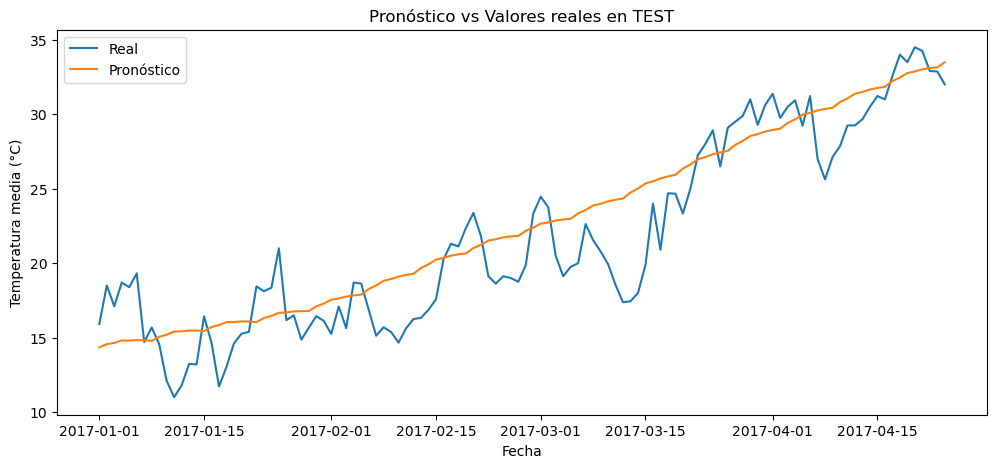

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Serie real en TEST
plt.plot(df_test["ds"], df_test["y"], label="Real")

# Pronóstico del modelo en TEST
plt.plot(df_test["ds"], y_pred, label="Pronóstico")

plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Temperatura media (°C)")
plt.title("Pronóstico vs Valores reales en TEST")
plt.show()

 📈 **Pronóstico vs Valores Reales en TEST**

El gráfico muestra la comparación entre los valores **reales** de la temperatura media diaria (°C) y los valores **pronosticados** por el modelo **Prophet** en el conjunto de **TEST**.

---

🔹 **Ejes del gráfico**
- **Eje X (horizontal):** Fechas (enero – abril de 2017).  
- **Eje Y (vertical):** Temperatura media diaria (°C).

---

🔹 **Líneas del gráfico**
- **Azul – Real:** valores observados de la temperatura (`y_true`), con alta variabilidad día a día.  
- **Naranja – Pronóstico:** valores estimados por Prophet (`y_pred`), que siguen la tendencia general pero suavizan las fluctuaciones.

---

🔹 **Interpretación**
- El modelo **captura bien la tendencia ascendente** de la temperatura a lo largo del periodo.  
- Prophet produce una curva **suavizada**, que **no refleja del todo los picos y valles diarios**.  
- Esto es esperado: Prophet está diseñado para identificar **tendencias y estacionalidades** más que variaciones abruptas.


## Parte 2: Las métricas de desempeño más usadas: RMSE, MAE y MAPE

In [24]:
# Variables reales y predichas
y = y_true
y_pred = y_pred

# Cálculo de errores
mse = np.mean((y - y_pred)**2)
rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.2f} °C  (MSE: {mse:.2f} °C²)")


RMSE: 2.66 °C  (MSE: 7.09 °C²)


📊 **Métricas de Evaluación del Modelo (TEST)**

Al evaluar las predicciones de Prophet sobre el conjunto de **TEST**, se obtuvieron los siguientes resultados:

- **RMSE = 2.66 °C**  
- **MSE = 7.09 °C²**

---

🔹 **Interpretación de las métricas**
- **MSE (Error Cuadrático Medio):**  
  Mide el error promedio al cuadrado entre los valores reales y pronosticados.  
  - Un valor de **7.09 °C²** indica que, en promedio, el error cuadrático es relativamente bajo considerando la escala de la temperatura (10–35 °C).

- **RMSE (Raíz del Error Cuadrático Medio):**  
  Es la raíz cuadrada del MSE y se expresa en las mismas unidades de la variable (°C).  
  - Un valor de **2.66 °C** significa que, en promedio, las predicciones se desvían aproximadamente **2.7 grados Celsius** respecto a los valores reales.

---

In [26]:
# Calcular MAE
mae = np.mean(np.abs(y - y_pred))

print(f"MAE: {mae:.2f} °C")

MAE: 2.19 °C


📊 **Métrica MAE en TEST**

El modelo Prophet, al evaluarse sobre el conjunto de **TEST**, obtuvo el siguiente resultado:

- **MAE = 2.19 °C**

---
🔹 **Interpretación**
- Un **MAE = 2.19 °C** significa que, en promedio, las predicciones del modelo Prophet se desvían **2.2 grados Celsius** respecto a los valores reales de temperatura media diaria.  
- Este nivel de error es razonable considerando la variabilidad del clima y la escala de la temperatura (≈10 °C a 35 °C).  

In [27]:
# Calcular MAPE
mape = np.mean(np.abs((y - y_pred) / y)) * 100

print(f"MAPE: {mape:.2f}%")


MAPE: 11.62%


📊 **Métrica MAPE en TEST**

El modelo Prophet, al evaluarse sobre el conjunto de **TEST**, obtuvo el siguiente resultado:

- **MAPE = 11.62%**

---
🔹 **Interpretación**
- Un **MAPE de 11.62%** significa que, en promedio, las predicciones del modelo Prophet se desvían un **11.6% respecto a los valores reales** de la temperatura media diaria.  
- En términos prácticos, si la temperatura real fuera de **25 °C**, el modelo tendría un error medio de alrededor de **±2.9 °C** (25 × 0.116 ≈ 2.9).

---

✅ **Conclusión**
- El desempeño del modelo es **aceptable para pronósticos de tendencia general**.  
- Un MAPE por debajo del **15%** suele considerarse razonable en aplicaciones de predicción de series temporales, por lo que el resultado indica un modelo confiable para proyecciones globales, aunque no exacto a nivel diario.
